In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. pandas → rad s tabličnim podacima
2. numpy → numeričke operacije (mean, NaN)
3. matplotlib → osnovni grafovi
4. seaborn → napredna vizualizacija

In [ ]:

df = pd.read_csv('movies_big_dirty_dataset.csv')

In [ ]:
df.head()

,title,year,genre,rating,votes,duration
0,the shawshank redemption,NaN,NaN,9.3,2500000,142
1,the godfather,NaN,NaN,9.2,1800000,175
2,the dark knight,NaN,NaN,9.0,2700000,152
3,pulp fiction,NaN,NaN,8.9,2100000,154
4,forrest gump,NaN,NaN,8.8,2000000,142


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             410 non-null    object 
 1   genre             410 non-null    object 
 2   year              410 non-null    int64  
 3   runtime           410 non-null    int64  
 4   rating            410 non-null    float64
 5   votes             410 non-null    int64  
 6   revenue_millions  379 non-null    float64
 7   metascore         410 non-null    int64  
 8   director          410 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 29.0+ KB


In [ ]:
df.describe()

,year,runtime,rating,votes,revenue_millions,metascore
count,410.000000,410.000000,410.000000,410.000000,379.000000,410.000000
mean,2000.863415,138.434146,7.335854,532352.614634,1011.556913,70.329268
std,12.092992,35.970129,1.322536,288995.983684,732.122514,17.191610
min,1980.000000,80.000000,5.000000,16154.000000,21.460000,40.000000
25%,1991.000000,106.250000,6.200000,288260.750000,487.475000,57.000000
50%,2001.000000,137.000000,7.400000,551256.000000,981.600000,70.000000
75%,2011.000000,171.000000,8.500000,780851.000000,1473.135000,85.000000
max,2023.000000,199.000000,9.500000,999156.000000,10000.000000,99.000000


In [ ]:
df.isnull().sum()

,0
title,0
genre,0
year,0
runtime,0
rating,0
votes,0
revenue_millions,31
metascore,0
director,0


In [ ]:
df.duplicated().sum()

np.int64(10)

In [ ]:
df["genre"].unique()

array(['Comedy', 'Horror', 'Sci-Fi', 'Drama', 'Action'], dtype=object)

In [ ]:
df["title"] = df["title"].str.strip()

In [ ]:
df["title"] = df["title"].str.lower().str.title()
df["genre"] = df["genre"].str.lower().str.title()

In [ ]:
df["year"] = df["year"].fillna(np.mean(df["year"]))
df["genre"] = df["genre"].fillna("Unknown")

In [ ]:
df["year"] = df["year"].astype(int)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [ ]:
df["genre"] = df["genre"].str.split(",")
df = df.explode("genre")
df["genre"] = df["genre"].str.strip()

In [ ]:
np.mean(df["rating"])

np.float64(7.336)

In [ ]:
df["rating"].mean()

np.float64(8.927536231884059)

In [ ]:
df.groupby("genre")["rating"].mean()

,rating
genre,
Action,7.288636
Comedy,7.578495
Drama,7.264384
Horror,7.274286
Sci-Fi,7.219737


In [ ]:
df.groupby("genre")["votes"].mean()

,votes
genre,
Action,545518.034091
Comedy,535282.860215
Drama,562392.068493
Horror,486595.471429
Sci-Fi,523234.578947


In [ ]:
df.sort_values(by="rating", ascending=False).head()

,title,genre,year,runtime,rating,votes,revenue_millions,metascore,director
250,Movie_250,Action,2011,173,9.5,884829,630.51,78,Scorsese
212,Movie_212,Sci-Fi,2011,118,9.5,895691,1984.39,65,Cameron
272,Movie_272,Action,2002,110,9.5,757512,1387.40,69,Spielberg
359,Movie_359,Horror,2011,134,9.5,156470,1531.10,73,Spielberg
179,Movie_179,Action,2020,155,9.5,816481,701.67,69,Nolan


In [ ]:
df["genre"].value_counts()

,count
genre,
Drama,91
Crime,62
Action,31
"Action, Sci-Fi",30
"Crime, Thriller",30
drama,12
crime,8
action,4
"action, sci-fi",4


In [ ]:
df[df["rating"] > 10]

,title,genre,year,runtime,rating,votes,revenue_millions,metascore,director


In [ ]:
df.loc[:, "title"] = df["title"].replace({
    "The Dark Knigt": "The Dark Knight"
})

VIZUALIZACIJA

<Axes: xlabel='genre', ylabel='count'>

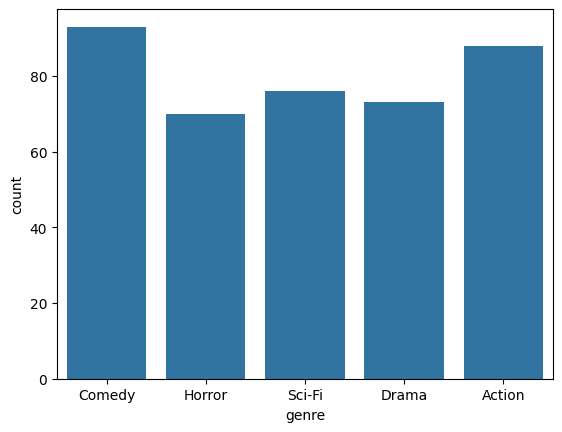

In [ ]:
sns.countplot(data=df, x="genre")

<Axes: xlabel='genre', ylabel='rating'>

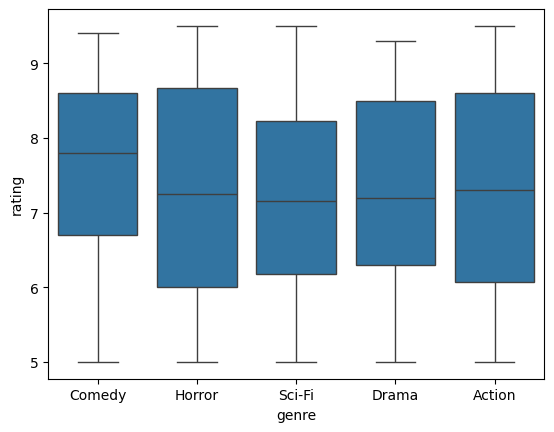

In [ ]:
sns.boxplot(data=df, x="genre", y="rating")

<Axes: xlabel='votes', ylabel='rating'>

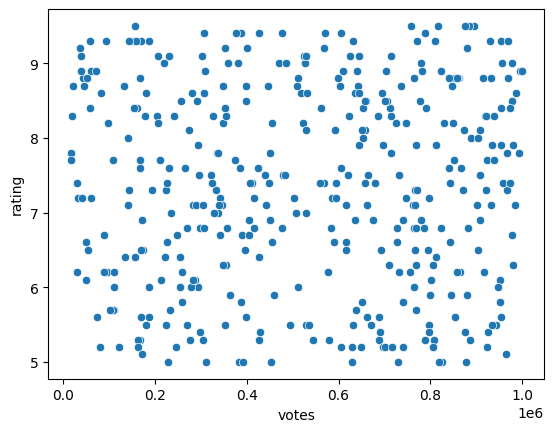

In [ ]:
sns.scatterplot(data=df, x="votes", y="rating")

<Axes: >

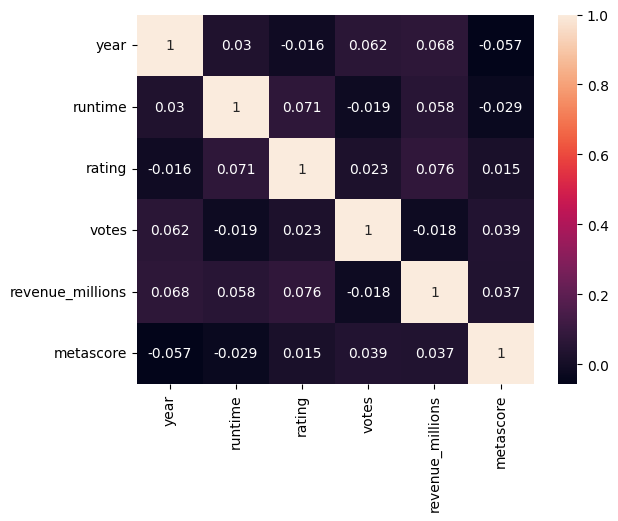

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Ovaj dataset omogućuje analizu filmske industrije kroz podatke o filmovima, njihovim žanrovima,ocjenama i popularnosti među korisnicima.Dataset služi za otkrivanje obrazaca u filmskim podacima,usporedbu žanrova,te proučavanje odnosa između ocjena filmova i broja glasova korisnika.

Kroz proces čišćenja podataka uklonjeni su duplikati,ispravljene nepravilnosti i popunjene nedostajuće vrijednosti,čime je dataset postao prikladan za daljnju analizu.Analiza je pokazala kako različiti žanrovi imaju različitu popularnost i prosječne ocjene,dok vizualizacije omogućuju lakše razumijevanje odnosa među podacima.

Na temelju dobivenih rezultata može se zaključiti da dataset pruža korisne informacije za analizu trendova u filmskoj industriji te može poslužiti kao osnova za buduće projekte poput sustava preporuke filmova,prediktivne analize popularnosti filmova ili detaljnijih statističkih istraživanja.